# 1. Imports and Setup

In [1]:
import sys
import os
from collections import defaultdict

# Add the src directory to sys.path
sys.path.append(os.path.abspath("../src"))

import torch
import pandas as pd
import plotly.express as px
import ipywidgets as widgets
from IPython.display import display, Markdown

from abstractions.dsl.abstraction import Abstraction
from abstractions.dsl.core import Shape
from abstractions.data.generator import generate_dataset
from abstractions.learning.utils import add, get_singletons, get_pairs
from abstractions.primitives.visualization import show_boxes, print_tree
from abstractions.learning.abstraction_discovery import find_abstractions, integrate_abstractions
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

# 2. Utility and Helper Functions

In [2]:
def count_nodes(shape):
    """Recursively counts the number of nodes in a shape program."""
    if not hasattr(shape, "param_tuple"):
        return 1
    _, args = shape.param_tuple()
    return 1 + sum(count_nodes(arg) for arg in args)

def contains_abstraction(shape):
    """Recursively checks if a shape program contains an Abstraction node."""
    if isinstance(shape, Abstraction):
        return True
    if not hasattr(shape, 'param_tuple'):
        return False
    _, args = shape.param_tuple()
    return any(contains_abstraction(arg) for arg in args)

def extract_float_params(param_list):
    """Extracts only float or integer parameters from a list of parameter tuples."""
    return [
        [p for p in tup if isinstance(p, (float, int))]
        for tup in param_list
    ]

def make_df_from_structure(param_list):
    """Converts a list of parameters into a Pandas DataFrame with float columns."""
    float_data = extract_float_params(param_list)
    float_data = [row for row in float_data if len(row) > 0]
    if not float_data:
        return pd.DataFrame()
    
    df = pd.DataFrame(float_data)
    df.columns = [f"param_{i}" for i in range(df.shape[1])]
    return df

# 3. Reusable Visualization Widgets

In [3]:
def visualize_dataset_interactive(dataset):
    """Creates an interactive slider to view shapes in a dataset."""
    output = widgets.Output()
    index_slider = widgets.IntSlider(
        value=0, min=0, max=len(dataset) - 1, step=1,
        description='Shape Index:', continuous_update=False
    )

    def update_display(change):
        idx = change["new"]
        output.clear_output()
        with output:
            shape = dataset[idx]
            display(Markdown(f"### Shape #{idx}"))
            print_tree(shape)
            show_boxes(shape.get_box_list(), backend="plotly")

    index_slider.observe(update_display, names="value")
    display(Markdown("### Visualize Dataset"), index_slider, output)
    update_display({"new": 0}) # Initial display

def create_structure_scatterplot_widget(structures, title):
    """Creates a dropdown to generate scatter plots for different structures."""
    plot_dropdown = widgets.Dropdown(
        options=list(structures.keys()),
        description="Structure:",
        layout=widgets.Layout(width="60%"),
    )
    plot_output = widgets.Output()

    def plot_on_change(change):
        structure_name = change["new"]
        plot_output.clear_output()
        with plot_output:
            param_list = structures[structure_name]
            df = make_df_from_structure(param_list)
            display(Markdown(f"### `{structure_name}` – {len(df)} instances"))
            if df.empty or df.shape[1] == 0:
                print("No float parameters to visualize.")
                return
            
            fig = px.scatter(
                df, x="param_0", y="param_1" if df.shape[1] > 1 else None,
                title=f"Scatterplot of parameters for {structure_name}",
                hover_data=df.columns
            ) if df.shape[1] > 1 else px.histogram(df, x="param_0", nbins=50, title=f"Histogram for {structure_name}")
            fig.show()

    plot_dropdown.observe(plot_on_change, names="value")
    display(Markdown(f"### {title}"), plot_dropdown, plot_output)
    if list(structures.keys()):
        plot_dropdown.value = list(structures.keys())[0]

def create_reconstruction_plot_widget(models, structures, threshold):
    """Creates a widget to visualize model reconstruction error."""
    dropdown = widgets.Dropdown(options=list(models.keys()), description="Structure:")
    output = widgets.Output()

    def update_plot(change):
        name = change["new"]
        output.clear_output()
        with output:
            model = models[name]
            param_list = structures[name]
            df = make_df_from_structure(param_list)
            if df.empty:
                print("No float parameters to plot.")
                return

            data = torch.tensor(df.values, dtype=torch.float32)
            model.eval()
            with torch.no_grad():
                _, recon = model(data)
                error = torch.max(torch.abs(recon - data), dim=1)[0]
                df["well_explained"] = error < threshold
            
            fig = px.scatter(
                df, x="param_0", y="param_1", color="well_explained",
                color_discrete_map={True: "green", False: "red"},
                title=f"{name} — Reconstruction Quality (Error < {threshold})"
            )
            fig.show()

    dropdown.observe(update_plot, names="value")
    display(Markdown("### Well-Defined Plots (Reconstruction Quality)"), dropdown, output)
    if list(models.keys()):
        update_plot({"new": dropdown.value})

def create_comparison_widget(original_dataset, abstracted_dataset):
    """Creates a widget to compare original and abstracted shapes."""
    num_before = sum(count_nodes(s) for s in original_dataset)
    num_after = sum(count_nodes(s) for s in abstracted_dataset)
    abstracted_indices = [i for i, s in enumerate(abstracted_dataset) if contains_abstraction(s)]
    
    summary = f"Total nodes reduced from {num_before} to {num_after}. "
    summary += f"{len(abstracted_indices)} / {len(original_dataset)} shapes were abstracted."
    display(Markdown(f"### Before and After Abstraction\n**Summary:** {summary}"))

    options = [
        (f"Index {i} | Δ={count_nodes(original_dataset[i]) - count_nodes(s)}", i)
        for i, s in enumerate(abstracted_dataset) if i in abstracted_indices
    ]
    if not options:
        print("No shapes were successfully abstracted.")
        return

    dropdown = widgets.Dropdown(options=options, description="Shape:")
    output = widgets.Output()

    def show_comparison(idx):
        output.clear_output()
        with output:
            before, after = original_dataset[idx], abstracted_dataset[idx]
            display(Markdown(f"#### Comparing Shape Index: {idx}"))
            print(f"Node Count: {count_nodes(before)} → {count_nodes(after)}")
            
            print("\nOriginal DSL Tree:")
            #print_tree(before)
            print(before)
            print("\nAbstracted DSL Tree:")
            #print_tree(after)
            print(after)
            
            display(Markdown("##### Original Geometry"))
            show_boxes(before.get_box_list(), backend="plotly")
            display(Markdown("##### Abstracted Geometry"))
            show_boxes(after.get_box_list(), backend="plotly")
            
    dropdown.observe(lambda change: show_comparison(change["new"]), names="value")
    display(dropdown, output)
    show_comparison(options[0][1])


# 4. Initial Abstraction

In [4]:
# 1.1. Generate and Visualize Dataset
print("--- PHASE 1: INITIAL ABSTRACTION ---")
dataset = (
    generate_dataset("chair_1", 1000) +
    generate_dataset("chair_2", 1000) +
    generate_dataset("chair_3", 1000)
)
visualize_dataset_interactive(dataset)

--- PHASE 1: INITIAL ABSTRACTION ---


### Visualize Dataset

IntSlider(value=0, continuous_update=False, description='Shape Index:', max=2999)

Output()

In [5]:
# 1.2. Generate Structures and Visualize Parameters
print("\nGenerating structures (singletons and pairs)...")
singletons = get_singletons(dataset)
pairs = get_pairs(dataset)
structures = add(singletons, pairs)
print(f"Found {len(structures)} unique structures.")
create_structure_scatterplot_widget(structures, "Initial Parameter Distribution")


Generating structures (singletons and pairs)...
Found 10 unique structures.


### Initial Parameter Distribution

Dropdown(description='Structure:', layout=Layout(width='60%'), options=('Union', 'Move', 'Rect', 'SymRef', 'Un…

Output()

In [6]:
# 1.3. Find Abstractions and Visualize Quality
print("\nFinding abstractions for structures...")
models, _ = find_abstractions(structures, retrain_iterations=1, error_threshold=0.01)
print(f"Trained models for {len(models)} structures.")
create_reconstruction_plot_widget(models, structures, threshold=0.01)


Finding abstractions for structures...
Iteration 1/1: training model for Move on 9000 structures.
Trained model for Move. Final train loss: 0.04794118281268905
Iteration 1/1: training model for Rect on 12000 structures.
Trained model for Rect. Final train loss: 0.0387247728897219
Iteration 1/1: training model for Union(Move, Rect) on 2000 structures.
Trained model for Union(Move, Rect). Final train loss: 0.016540568612981588
Iteration 1/1: training model for Union(Move, Move) on 2000 structures.
Trained model for Union(Move, Move). Final train loss: 0.007430358542478643
Iteration 1/1: training model for Union(Rect, Union) on 1000 structures.
Trained model for Union(Rect, Union). Final train loss: 0.039065463468432426
Iteration 1/1: training model for Union(Move, Union) on 1000 structures.
Trained model for Union(Move, Union). Final train loss: 0.055410260101780295
Trained models for 6 structures.


### Well-Defined Plots (Reconstruction Quality)

Dropdown(description='Structure:', options=('Move', 'Rect', 'Union(Move, Rect)', 'Union(Move, Move)', 'Union(R…

Output()

In [7]:
# 1.4. Apply Abstractions and Compare
print("\nApplying abstractions to dataset...")
abstracted_dataset_v1 = integrate_abstractions(dataset, models, error_threshold=0.03)
create_comparison_widget(dataset, abstracted_dataset_v1)


Applying abstractions to dataset...


### Before and After Abstraction
**Summary:** Total nodes reduced from 76000 to 47383. 2798 / 3000 shapes were abstracted.

Dropdown(description='Shape:', options=(('Index 0 | Δ=5', 0), ('Index 1 | Δ=5', 1), ('Index 3 | Δ=5', 3), ('In…

Output()

# 5. Abstraction after Clustering


--- PHASE 2: ABSTRACTION ON CLUSTERED STRUCTURES ---

Attempting to cluster structures: ['Move']...

--- Clustering 'Move' ---
Found 3 clusters for 'Move'.


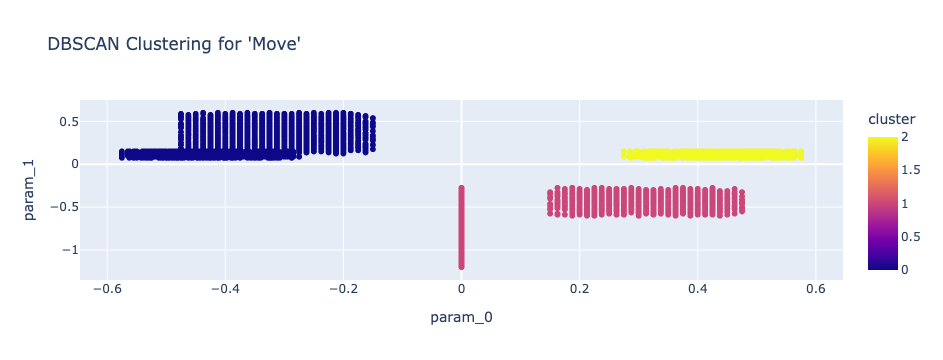

In [8]:
print("\n--- PHASE 2: ABSTRACTION ON CLUSTERED STRUCTURES ---")

# 2.1. Cluster a list of specified structures
# Define which structures you want to attempt to cluster.
structure_names_to_cluster = ["Move"] # CHANGED: Now a list
all_clustered_structures = {}

print(f"\nAttempting to cluster structures: {structure_names_to_cluster}...")

for structure_name in structure_names_to_cluster:
    print(f"\n--- Clustering '{structure_name}' ---")
    
    # Get the parameters for the current structure
    params = structures.get(structure_name)
    if not params:
        print(f"Structure '{structure_name}' not found or is empty. Skipping.")
        continue
        
    df = make_df_from_structure(params)

    if df.empty or df.shape[1] == 0:
        print(f"No float parameters to cluster for '{structure_name}'. Skipping.")
        continue

    # Normalize and cluster using DBSCAN
    X = StandardScaler().fit_transform(df.values)
    # Note: You might need to tune eps and min_samples for different structures
    labels = DBSCAN(eps=0.5, min_samples=10).fit_predict(X)
    df["cluster"] = labels
    
    # Visualize the clusters for the current structure
    num_clusters_found = len(set(labels)) - (1 if -1 in labels else 0)
    print(f"Found {num_clusters_found} clusters for '{structure_name}'.")
    
    fig = px.scatter(
        df, 
        x="param_0", 
        y="param_1" if "param_1" in df.columns else None, 
        color="cluster",
        title=f"DBSCAN Clustering for '{structure_name}'"
    )
    fig.show()

    # Create new, more specific structures based on the clusters found
    cluster_map = defaultdict(list)
    for i, label in enumerate(labels):
        if label != -1:  # Ignore noise points
            # Create a unique name for the new clustered structure
            new_structure_name = f"{structure_name.lower()}_cluster_{label}"
            cluster_map[new_structure_name].append(params[i])
            
    # Add the newly found clusters to our collection
    all_clustered_structures.update(dict(cluster_map))

In [9]:
# 2.2. Create Final Structure Set for Re-training
print("\n------------------------------------")
print(f"\nSaved a total of {len(all_clustered_structures)} new structures from clustering.")

# Start with all the new clustered structures
final_structures = all_clustered_structures.copy()

# Add back all original structures that were NOT targeted for clustering
for key, val in structures.items():
    if key not in structure_names_to_cluster:
        final_structures[key] = val
        
print(f"Created a new set of {len(final_structures)} total structures for re-training.")
print("Final structure keys:", list(final_structures.keys()))


------------------------------------

Saved a total of 3 new structures from clustering.
Created a new set of 12 total structures for re-training.
Final structure keys: ['move_cluster_0', 'move_cluster_1', 'move_cluster_2', 'Union', 'Rect', 'SymRef', 'Union(Move, Rect)', 'Union(Union, SymRef)', 'Union(Move, Move)', 'Union(Union, Union)', 'Union(Rect, Union)', 'Union(Move, Union)']


In [10]:
# 2.3. Find Abstractions on Clustered Structures
print("\nFinding abstractions for the new clustered structures...")
# The rest of the script continues from here without changes
models_v2, _ = find_abstractions(final_structures, retrain_iterations=1, error_threshold=0.01)
print(f"Trained models for {len(models_v2)} new structures.")
create_reconstruction_plot_widget(models_v2, final_structures, threshold=0.01)


Finding abstractions for the new clustered structures...
Iteration 1/1: training model for move_cluster_0 on 4000 structures.
Trained model for move_cluster_0. Final train loss: 0.04858752895915319
Iteration 1/1: training model for move_cluster_1 on 4000 structures.
Trained model for move_cluster_1. Final train loss: 0.02553886127850366
Iteration 1/1: training model for move_cluster_2 on 1000 structures.
Trained model for move_cluster_2. Final train loss: 0.021377181285060942
Iteration 1/1: training model for Rect on 12000 structures.
Trained model for Rect. Final train loss: 0.03912313212145199
Iteration 1/1: training model for Union(Move, Rect) on 2000 structures.
Trained model for Union(Move, Rect). Final train loss: 0.03800157562363893
Iteration 1/1: training model for Union(Move, Move) on 2000 structures.
Trained model for Union(Move, Move). Final train loss: 0.007904240555944853
Iteration 1/1: training model for Union(Rect, Union) on 1000 structures.
Trained model for Union(Rect

### Well-Defined Plots (Reconstruction Quality)

Dropdown(description='Structure:', options=('move_cluster_0', 'move_cluster_1', 'move_cluster_2', 'Rect', 'Uni…

Output()

In [11]:
# 2.4. Apply New Abstractions and Compare
print("\nApplying new, clustered abstractions to the original dataset...")
abstracted_dataset_v2 = integrate_abstractions(dataset, models_v2, error_threshold=0.03)
create_comparison_widget(dataset, abstracted_dataset_v2)


Applying new, clustered abstractions to the original dataset...


### Before and After Abstraction
**Summary:** Total nodes reduced from 76000 to 50838. 2480 / 3000 shapes were abstracted.

Dropdown(description='Shape:', options=(('Index 0 | Δ=5', 0), ('Index 3 | Δ=5', 3), ('Index 4 | Δ=5', 4), ('In…

Output()

In [12]:
print("--- Dataset Comparison Summary ---")

# Calculate metrics for Original Dataset
original_total_nodes = sum(count_nodes(s) for s in dataset)
original_shapes_count = len(dataset)

print(f"\nOriginal Dataset (Initial State):")
print(f"  Total Nodes: {original_total_nodes}")
print(f"  Total Shapes: {original_shapes_count}")


# Calculate metrics for Phase 1 Abstracted Dataset
abstracted_v1_total_nodes = sum(count_nodes(s) for s in abstracted_dataset_v1)
abstracted_v1_shapes_abstracted_in_phase = sum(1 for s in abstracted_dataset_v1 if contains_abstraction(s))

print(f"\nAfter Phase 1: Base Primitive Abstractions:")
print(f"  Total Nodes: {abstracted_v1_total_nodes}")
print(f"  Nodes Reduced from Original: {original_total_nodes - abstracted_v1_total_nodes}")
print(f"  Shapes Abstracted in this Phase: {abstracted_v1_shapes_abstracted_in_phase} / {original_shapes_count}")


# Calculate metrics for Phase 2 Abstracted Dataset
abstracted_v2_total_nodes = sum(count_nodes(s) for s in abstracted_dataset_v2)
abstracted_v2_shapes_abstracted_in_phase = sum(1 for s in abstracted_dataset_v2 if contains_abstraction(s))

print(f"\nAfter Phase 2: Clustered Primitive Abstractions:")
print(f"  Total Nodes: {abstracted_v2_total_nodes}")
print(f"  Nodes Reduced from Phase 1: {abstracted_v1_total_nodes - abstracted_v2_total_nodes}")
print(f"  Shapes Abstracted in this Phase: {abstracted_v2_shapes_abstracted_in_phase} / {original_shapes_count}")

--- Dataset Comparison Summary ---

Original Dataset (Initial State):
  Total Nodes: 76000
  Total Shapes: 3000

After Phase 1: Base Primitive Abstractions:
  Total Nodes: 47383
  Nodes Reduced from Original: 28617
  Shapes Abstracted in this Phase: 2798 / 3000

After Phase 2: Clustered Primitive Abstractions:
  Total Nodes: 50838
  Nodes Reduced from Phase 1: -3455
  Shapes Abstracted in this Phase: 2480 / 3000
